In [1]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt

In [2]:
# 🔹 Load dataset (MNIST)
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

In [3]:
# 🔹 Normalize data (0-255 → 0-1)
x_train

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

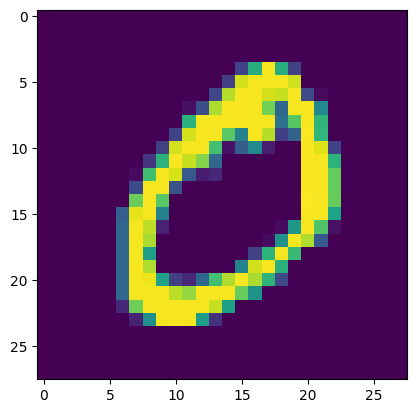

In [4]:
plt.imshow(x_train[1])

In [5]:
# 🔹 Normalize data (0-255 → 0-1)
x_train = x_train / 255.0
x_test = x_test / 255.0

In [6]:
# 🔹 Flatten (28x28 → 784)
x_train = x_train.reshape(-1, 28*28)
x_test = x_test.reshape(-1, 28*28)

In [7]:
# 🔹 Build ANN Model

model = Sequential()

model.add(Dense(128, activation='relu', input_shape = (784,)))
model.add(Dense(64, activation='relu'))
model.add(Dense(10, activation='softmax'))  # 10 classes


c:\Users\ABDULLAH AL MASUM\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
# 🔹 Compile Model

model.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])

In [9]:
# 🔹 Train Model

history = model.fit(x_train, y_train, epochs = 10, validation_split = 0.1)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9258 - loss: 0.2514 - val_accuracy: 0.9668 - val_loss: 0.1193
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9674 - loss: 0.1072 - val_accuracy: 0.9763 - val_loss: 0.0864
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9767 - loss: 0.0762 - val_accuracy: 0.9728 - val_loss: 0.0933
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9823 - loss: 0.0563 - val_accuracy: 0.9758 - val_loss: 0.0888
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9856 - loss: 0.0446 - val_accuracy: 0.9753 - val_loss: 0.0912
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9889 - loss: 0.0355 - val_accuracy: 0.9790 - val_loss: 0.0833
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9899 - loss: 0.0303 - val_accuracy: 0.9767 - val_loss: 0.0921
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9922 - loss: 0.0238 - 

In [10]:
# 🔹 Evaluate
test_loss, test_acc = model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9748 - loss: 0.1041


In [11]:
print(f"\nTest Accuracy: {test_acc}")


Test Accuracy: 0.9747999906539917


In [12]:
y_pred = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


In [13]:
y_pred = y_pred.argmax(axis=1)

In [14]:
from sklearn.metrics import accuracy_score

In [15]:
accuracy_score(y_test, y_pred)

0.9748

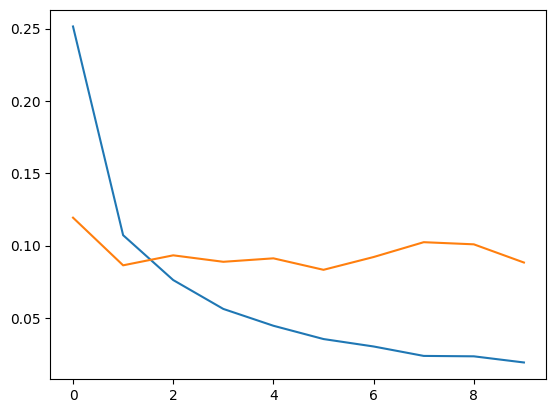

In [16]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

In [17]:
print('Actual : ', y_pred[5])
print('Actual : ', y_test[5])

Actual :  1
Actual :  1


In [18]:
model.predict(x_train[1].reshape(-1, 28*28)).argmax(axis = 1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


array([0])